Raw Dataset Shape: (69975, 12)
Feature Dataset Shape: (69926, 26)

New Columns (15): {'is_long_distance', 'night_peak_conflict', 'is_weekend', 'week_of_year', 'traffic_weather_risk', 'order_hour_cos', 'is_night', 'is_peak_hour', 'order_hour_sin', 'expected_time_no_traffic', 'day_of_month', 'distance_bucket', 'month_sin', 'month_cos', 'month'}
Missing Columns (1): {'order_id'}

Target Variable Check:
Raw Mean: 9.153710325116114
Feature Mean: 9.156379458284473


/tmp/ipykernel_244111/2968303764.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Raw Data', 'Feature Data'], y=[df_raw.shape[1], df_feature.shape[1]], ax=ax1, palette='viridis')
/tmp/ipykernel_244111/2968303764.py:50: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_raw['delivery_time_hours'], label='Raw Data', shade=True, color='blue', ax=ax3)
/tmp/ipykernel_244111/2968303764.py:51: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_feature['delivery_time_hours'], label='Feature Data', shade=True, color='orange', ax=ax3, linestyle='--')
/tmp/ipykernel_244111/2968303764.py:62: FutureWarn


Feature Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69926 entries, 0 to 69925
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   origin_city               69926 non-null  object 
 1   destination_city          69926 non-null  object 
 2   distance_km               69926 non-null  float64
 3   distance_bucket           69926 non-null  object 
 4   is_long_distance          69926 non-null  int64  
 5   vehicle_type              69926 non-null  object 
 6   order_date                69926 non-null  object 
 7   order_hour                69926 non-null  int64  
 8   order_hour_sin            69926 non-null  float64
 9   order_hour_cos            69926 non-null  float64
 10  weekday                   69926 non-null  object 
 11  weather                   69926 non-null  object 
 12  temperature               69926 non-null  float64
 13  traffic_level             69926 non-nu

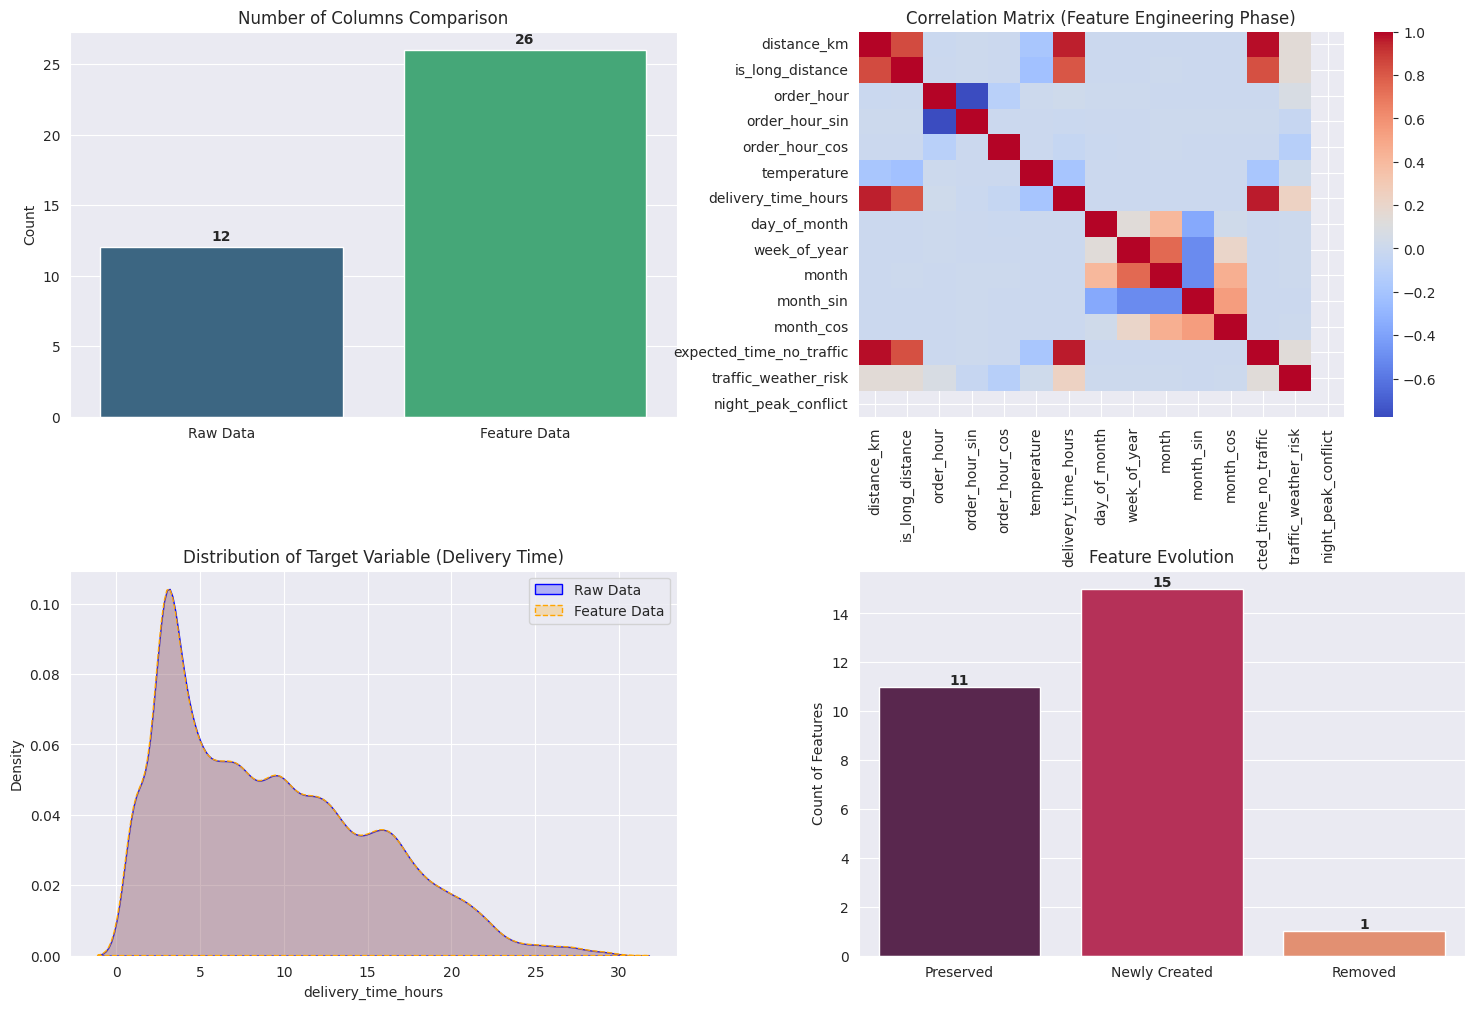

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load both datasets
df_raw = pd.read_csv('dataset/raw_data.csv')
df_feature = pd.read_csv('dataset/feature_data_v2.csv')

# 1. Structural Comparison
print("Raw Dataset Shape:", df_raw.shape)
print("Feature Dataset Shape:", df_feature.shape)

raw_cols = set(df_raw.columns)
feature_cols = set(df_feature.columns)

new_cols = feature_cols - raw_cols
missing_cols = raw_cols - feature_cols

print(f"\nNew Columns ({len(new_cols)}):", new_cols)
print(f"Missing Columns ({len(missing_cols)}):", missing_cols)

# 2. Check if target variable is preserved
print("\nTarget Variable Check:")
print("Raw Mean:", df_raw['delivery_time_hours'].mean())
print("Feature Mean:", df_feature['delivery_time_hours'].mean())

# 3. Visualization

# Set up the figure for multiple subplots
fig = plt.figure(figsize=(18, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Plot 1: Number of Columns Comparison
ax1 = fig.add_subplot(2, 2, 1)
sns.barplot(x=['Raw Data', 'Feature Data'], y=[df_raw.shape[1], df_feature.shape[1]], ax=ax1, palette='viridis')
ax1.set_title('Number of Columns Comparison')
ax1.set_ylabel('Count')
for i, v in enumerate([df_raw.shape[1], df_feature.shape[1]]):
    ax1.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Plot 2: Correlation Heatmap of Numeric Features in Feature Dataset
# Filter only numeric columns
numeric_feature_df = df_feature.select_dtypes(include=['float64', 'int64'])
ax2 = fig.add_subplot(2, 2, 2)
sns.heatmap(numeric_feature_df.corr(), annot=False, cmap='coolwarm', ax=ax2)
ax2.set_title('Correlation Matrix (Feature Engineering Phase)')

# Plot 3: Target Variable Distribution Check (Overlay)
ax3 = fig.add_subplot(2, 2, 3)
sns.kdeplot(df_raw['delivery_time_hours'], label='Raw Data', shade=True, color='blue', ax=ax3)
sns.kdeplot(df_feature['delivery_time_hours'], label='Feature Data', shade=True, color='orange', ax=ax3, linestyle='--')
ax3.set_title('Distribution of Target Variable (Delivery Time)')
ax3.legend()

# Plot 4: Feature Categories Count
# Categorizing columns
original_count = len(raw_cols & feature_cols)
new_count = len(new_cols)
removed_count = len(missing_cols)

ax4 = fig.add_subplot(2, 2, 4)
sns.barplot(x=['Preserved', 'Newly Created', 'Removed'], y=[original_count, new_count, removed_count], ax=ax4, palette='rocket')
ax4.set_title('Feature Evolution')
ax4.set_ylabel('Count of Features')
for i, v in enumerate([original_count, new_count, removed_count]):
    ax4.text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# Save the figure
plt.savefig('visualizations/comparison_analysis.png')

print("\nFeature Dataset Info:")
print(df_feature.info())
print("\nFirst 5 rows of Feature Dataset:")
print(df_feature.head())